--- DATA AWAL TERDETEKSI KOTOR ---
Ukuran data awal: (203, 4)
Jumlah baris duplikat: 3
Missing values Pendapatan: 6

--- DATA SELESAI DIBERSIHKAN ---
Ukuran data sekarang: (200, 4)



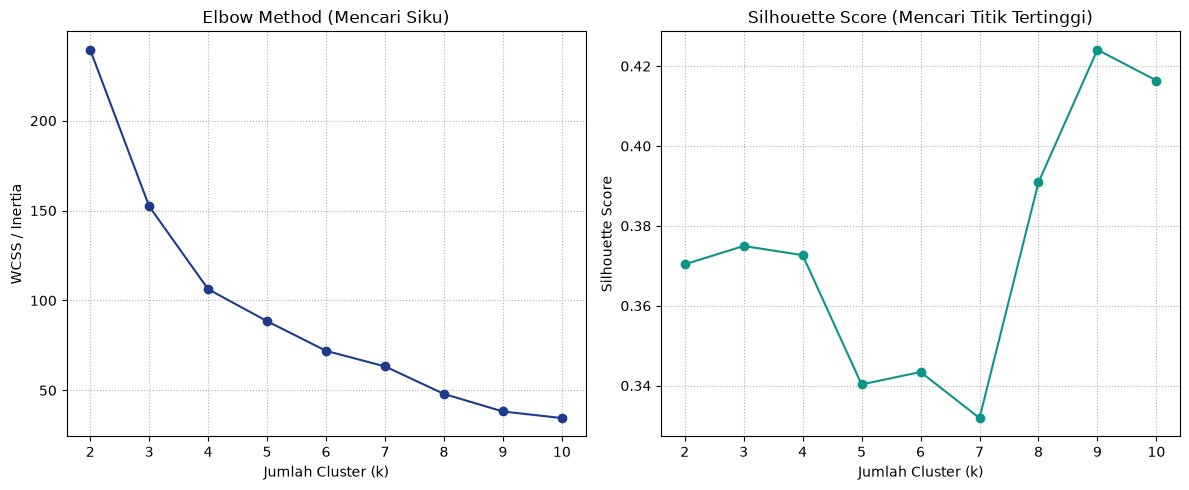

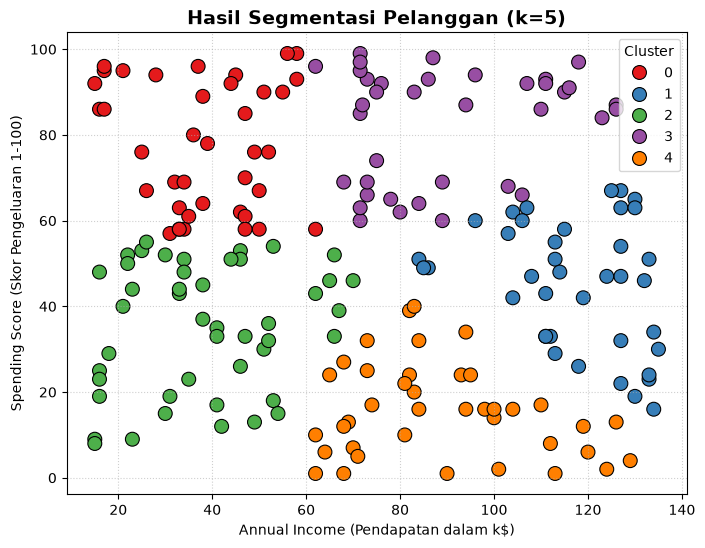

--- Rata-rata Karakteristik Tiap Cluster ---
           Age  Annual_Income_k$  Spending_Score
Cluster                                         
0        42.15             38.44           77.31
1        43.26            117.13           45.15
2        44.20             38.35           34.98
3        44.22             89.57           82.41
4        43.21             88.95           15.62


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

np.random.seed(42)
data = {
    'CustomerID': range(1, 201),
    'Age': np.random.randint(18, 70, size=200),
    'Annual_Income_k$': np.random.randint(15, 137, size=200),
    'Spending_Score': np.random.randint(1, 100, size=200)
}
df = pd.DataFrame(data)


df.loc[15:20, 'Annual_Income_k$'] = np.nan
df.loc[50:52, 'Spending_Score'] = np.nan
df = pd.concat([df, df.iloc[[10, 25, 40]]], ignore_index=True)

print("--- DATA AWAL TERDETEKSI KOTOR ---")
print(f"Ukuran data awal: {df.shape}")
print(f"Jumlah baris duplikat: {df.duplicated().sum()}")
print(f"Missing values Pendapatan: {df['Annual_Income_k$'].isnull().sum()}")


df = df.drop_duplicates()


df['Annual_Income_k$'] = df['Annual_Income_k$'].fillna(df['Annual_Income_k$'].median())
df['Spending_Score'] = df['Spending_Score'].fillna(df['Spending_Score'].median())


X = df[['Annual_Income_k$', 'Spending_Score']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\n--- DATA SELESAI DIBERSIHKAN ---")
print(f"Ukuran data sekarang: {df.shape}\n")

wcss = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))


plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(K_range, wcss, marker='o', color='#1e3a8a')
plt.title('Elbow Method (Mencari Siku)')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('WCSS / Inertia')
plt.grid(True, linestyle=':')

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, marker='o', color='#0d9488')
plt.title('Silhouette Score (Mencari Titik Tertinggi)')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Silhouette Score')
plt.grid(True, linestyle=':')
plt.tight_layout()
plt.show()


kmeans_final = KMeans(n_clusters=5, init='k-means++', random_state=42)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=df['Annual_Income_k$'], 
    y=df['Spending_Score'], 
    hue=df['Cluster'], 
    palette='Set1', 
    s=100, 
    edgecolor='black'
)
plt.title('Hasil Segmentasi Pelanggan (k=5)', fontsize=14, fontweight='bold')
plt.xlabel('Annual Income (Pendapatan dalam k$)')
plt.ylabel('Spending Score (Skor Pengeluaran 1-100)')
plt.legend(title='Cluster')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print("--- Rata-rata Karakteristik Tiap Cluster ---")
print(df.groupby('Cluster')[['Age', 'Annual_Income_k$', 'Spending_Score']].mean().round(2))